In [1]:
import pandas as pd

X_train = pd.read_parquet('/content/drive/MyDrive/Rome_AirBnB/Datasets/X_train_final.parquet')
X_val = pd.read_parquet('/content/drive/MyDrive/Rome_AirBnB/Datasets/X_val_final.parquet')
X_test = pd.read_parquet('/content/drive/MyDrive/Rome_AirBnB/Datasets/X_test_final.parquet')

y_train = pd.read_parquet('/content/drive/MyDrive/Rome_AirBnB/Datasets/y_train1.parquet').squeeze()
y_val = pd.read_parquet('/content/drive/MyDrive/Rome_AirBnB/Datasets/y_val1.parquet').squeeze()
y_test = pd.read_parquet('/content/drive/MyDrive/Rome_AirBnB/Datasets/y_test1.parquet').squeeze()

print('X_train shape: ', X_train.shape)
print('X_val shape: ', X_val.shape)
print('X_test shape: ', X_test.shape)

print('y_train shape: ', y_train.shape)
print('y_val shape: ', y_val.shape)
print('y_test shape: ', y_test.shape)

X_train shape:  (26754, 212)
X_val shape:  (3344, 212)
X_test shape:  (3345, 212)
y_train shape:  (26754,)
y_val shape:  (3344,)
y_test shape:  (3345,)


These are the final processed train, validation and test sets from the previous notebook, where everything was analyzed and processed.

In [2]:
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

From the analysis done on the target column in the Rome_AirBnB_Analysis, we could see that 'price' column has some extreme outliers. Most of the prices are well below \$1000 per night, but there are prices close to $10000. That is big difference in scale, so transforming this column to log scale seems more efficient.

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluation_report(y_true_log, y_pred_log, model_name):
  y_true = np.expm1(y_true_log)
  y_pred = np.expm1(y_pred_log)

  r2 = r2_score(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mae = mean_absolute_error(y_true, y_pred)

  print(f"=== {model_name} ===")
  print(f"R^2 Score: {r2:.3f}")
  print(f"Root Mean Squared Error: {rmse:.2f}")
  print(f"Mean Absolute Error: {mae:.2f}")

The Baseline Model will be Ridge. It handles datasets like this one, with many sparse features, by shrinking large coefficients and preventing the model from overfitting.

And to use it the columns need to be scaled since this is a linear model and it requires that all the columns be on the same scale.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

ridge = Ridge(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ridge, X_train_scaled, y_train_log, cv=kf, scoring='neg_root_mean_squared_error')

print(f"Ridge 5-fold CV RMSE Score (log): {-cv_scores.mean():.2f} (+/- {cv_scores.std():.3f})")

Ridge 5-fold CV RMSE Score (log): 0.44 (+/- 0.021)


In [5]:
ridge.fit(X_train_scaled, y_train_log)
ridge_pred_log = ridge.predict(X_val_scaled)
evaluation_report(y_val_log, ridge_pred_log, 'Ridge Baseline')

=== Ridge Baseline ===
R^2 Score: 0.054
Root Mean Squared Error: 441.36
Mean Absolute Error: 76.06


In [6]:
r2_log_r = r2_score(y_val_log, ridge_pred_log)
print("R² (log scale):", r2_log_r)

R² (log scale): 0.4975984214773522


Baseline Model is performing very poorly. The model is explaining basically none of the variance the price (r2=0.054). And rmse is dominated by outliers which are present in the dataset.

In [7]:
import re

def clean_column_names(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in df.columns]
    return df

X_train_2 = clean_column_names(X_train)
X_val_2 = clean_column_names(X_val)
X_test_2 = clean_column_names(X_test)

In [8]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(random_state=42, learning_rate=0.05, colsample_bytree=0.8)
lgb_model.fit(X_train_2, y_train_log,eval_set=[(X_val_2, y_val_log)], eval_metric="rmse")
lgb_pred_log = lgb_model.predict(X_val_2, num_iteration=lgb_model.best_iteration_)
evaluation_report(y_val_log, lgb_pred_log, "LightGBM Base")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.102176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1949
[LightGBM] [Info] Number of data points in the train set: 26754, number of used features: 212
[LightGBM] [Info] Start training from score 4.965375
=== LightGBM Base ===
R^2 Score: 0.109
Root Mean Squared Error: 428.45
Mean Absolute Error: 74.03


Even with using LightGBM the performance is very bad. It looks very much like some extreme outliers are dominating the RMSE.

In [9]:
r2_log = r2_score(y_val_log, lgb_pred_log)
print("R² (log scale):", r2_log)

R² (log scale): 0.5473581332338004


But when comparing the prediction to the actual prices on the log scale we can see that the model is actually learning something. And it is explaining the half of the variance of price. When transformed back to the actual values the predictions are just getting crushed by few very extreme outliers.

Let's see if clipping the y_train will lead to better results comapred to using original y_train.

In [10]:
clip = y_train.quantile(0.99)
y_train_clipped = y_train.clip(upper=clip)
y_train_clipped_log = np.log1p(y_train_clipped)


lgb_model_c = lgb.LGBMRegressor(random_state=42, learning_rate=0.05, colsample_bytree=0.8)
lgb_model_c.fit(X_train_2, y_train_clipped_log,eval_set=[(X_val_2, y_val_log)], eval_metric="rmse")
lgb_pred_log_c = lgb_model_c.predict(X_val_2, num_iteration=lgb_model_c.best_iteration_)
evaluation_report(y_val_log, lgb_pred_log_c, "LightGBM Clipped Y")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.276404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1949
[LightGBM] [Info] Number of data points in the train set: 26754, number of used features: 212
[LightGBM] [Info] Start training from score 4.956307
=== LightGBM Clipped Y ===
R^2 Score: 0.057
Root Mean Squared Error: 440.73
Mean Absolute Error: 73.62


Clipping actually led to a decrease in the performance.

In [11]:
r2_log_c = r2_score(y_val_log, lgb_pred_log_c)
print("R² (log scale):", r2_log_c)

R² (log scale): 0.5423711485478402


In [12]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(learning_rate=0.05, colsample_bytree=0.8, eval_metric="rmse", random_state=42,)

xgb_model.fit(X_train, y_train_log,eval_set=[(X_val, y_val_log)],verbose=False,)

xgb_pred_log = xgb_model.predict(X_val)
evaluation_report(y_val_log, xgb_pred_log, "XGBoost")

=== XGBoost ===
R^2 Score: 0.140
Root Mean Squared Error: 421.00
Mean Absolute Error: 73.55


In [13]:
r2_log_x = r2_score(y_val_log, xgb_pred_log)
print("R² (log scale):", r2_log_x)

R² (log scale): 0.5520772062919337


XGBoostRegressor model performed, although marginally still better than Ridge or LightGBMRegressor. It had the highest performance accross all the metrics, so we will move on to tuning this model.

Optuna is more effiecient than random or grid based searches. It uses intelligent sampling and it also automatically stops unpromising trials early on.

In [14]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.1 MB/s eta 0:00:00


In [15]:
import optuna
from sklearn.metrics import r2_score, mean_absolute_error

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1
    }


    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train_log)

    preds_log = model.predict(X_val)

    log_r2 = r2_score(y_val_log, preds_log)

    preds = np.expm1(preds_log)
    mae = mean_absolute_error(y_val, preds)

    return log_r2, mae

study = optuna.create_study(directions=["maximize", "minimize"])
study.optimize(objective, n_trials=50)

pareto_trials = study.best_trials
best_by_log_r2 = max(pareto_trials, key=lambda t: t.values[0])

print(f"Best Trial Number: {best_by_log_r2.number}")
print(f"Highest Log R2:    {best_by_log_r2.values[0]:.5f}")
print(f"Associated MAE: {best_by_log_r2.values[1]:.5f}")
print("\nBest Parameters to use:")
print(best_by_log_r2.params)

[I 2026-07-06 17:18:45,202] A new study created in memory with name: no-name-c01746f0-33cd-431c-a0d2-8fab4b343b8b
[I 2026-07-06 17:19:31,293] Trial 0 finished with values: [0.5995358351333699, 70.16251625170548] and parameters: {'n_estimators': 1700, 'max_depth': 8, 'learning_rate': 0.0962061609525584, 'subsample': 0.9823722058441557, 'colsample_bytree': 0.8981459490426609, 'min_child_weight': 9, 'reg_alpha': 0.024501216844719356, 'reg_lambda': 4.33792530647055e-06}.
[I 2026-07-06 17:19:41,466] Trial 1 finished with values: [0.5887354890332512, 70.171807187596] and parameters: {'n_estimators': 700, 'max_depth': 4, 'learning_rate': 0.12518903911141793, 'subsample': 0.6187546826592576, 'colsample_bytree': 0.5880464998621427, 'min_child_weight': 7, 'reg_alpha': 0.00038104351483415487, 'reg_lambda': 6.68139801791375e-08}.
[I 2026-07-06 17:20:08,834] Trial 2 finished with values: [0.591679936320434, 70.89641236574455] and parameters: {'n_estimators': 2000, 'max_depth': 4, 'learning_rate': 0

Best Trial Number: 41
Highest Log R2:    0.63695
Associated MAE: 66.31011

Best Parameters to use:
{'n_estimators': 1500, 'max_depth': 10, 'learning_rate': 0.04364189539717061, 'subsample': 0.7971414811733797, 'colsample_bytree': 0.648734223270014, 'min_child_weight': 2, 'reg_alpha': 0.02503481004040766, 'reg_lambda': 8.979797733407837}


In [16]:
optuna.visualization.plot_pareto_front(study, target_names=["Log R2", "MAE"]).show()

Hyperparameter Tuning led us to the best performing model of this project. On trial 41, the model found via tuning acheived both the best r2 in log space so far (0.63695) and the best mae up to now (~66). This means that this model explains roughly 64% of variance in price and the predictions are, on average, off by around \$66.

In [17]:
best_params = best_by_log_r2.params

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train, y_train_log)

test_preds_log = final_model.predict(X_test)
test_preds = np.expm1(test_preds_log)

y_test_log = np.log1p(y_test)

final_test_log_r2 = r2_score(y_test_log, test_preds_log)
final_test_mae = mean_absolute_error(y_test, test_preds)

print("--- Final Evaluation Test Set ---")
print(f"Test Log R2: {final_test_log_r2:.3f}")
print(f"Test Raw MAE: {final_test_mae:.2f}")

--- Final Evaluation Test Set ---
Test Log R2: 0.667
Test Raw MAE: 62.69


Finally, after training the final model with the best found parameters from the hyperparameter tuning search before, we evaluate the model's performance on the on the unseen test set. This is our final model and it achieved the highest Log R^2 Score in this project of 0.667. And the raw MAE of 62.69 tells us the predictions made by this model are the closest to the real results out of all the predictins made by different models and model architectures. The Final Best Model is predicting the prices which are on average off by ~\$63 from the real price per night.

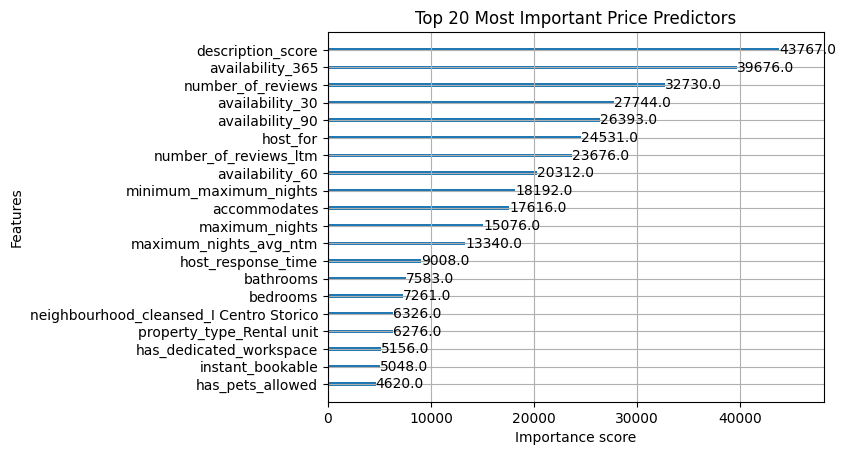

In [21]:
import matplotlib.pyplot as plt

xgb.plot_importance(final_model, max_num_features=20, importance_type='weight')
plt.title("Top 20 Most Important Price Predictors")
plt.show()

On the plot we see top 20 contributors to the price prediction.

We can see that some of the most important things is the description of the property, how available it is, is it highlt reviewed, how wlong has the host actually been renting the places, how many people it accommodates etc.

In [18]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, test_preds)

print(f"On average, our predictions are off by: {mape * 100:.2f}%")

xgb_base_preds = np.expm1(xgb_pred_log)
mape2 = mean_absolute_percentage_error(y_val, xgb_base_preds)

print(f"While the baseline XGBoost model was off by: {mape2 * 100:.2f}%")

On average, our predictions are off by: 25.80%
While the baseline XGBoost model was off by: 29.04%


We improved the mean absolute error by 4%.

In [20]:
mean_price = y_test.mean()
median_price = y_test.median()

error_vs_mean = (62.69 / mean_price) * 100
error_vs_median = (62.69 / median_price) * 100

print(f"Mean Price: ${mean_price:.2f}")
print(f"Median Price: ${median_price:.2f}")
print(f"The $62.69 error represents {error_vs_mean:.2f}% of the average price.")
print(f"The $62.69 error represents {error_vs_median:.2f}% of the median price.")

Mean Price: $191.37
Median Price: $134.00
The $62.69 error represents 32.76% of the average price.
The $62.69 error represents 46.78% of the median price.


The model is off by 33% of the average price and 46% of the median price. While there is still room for the improvement this is still an improvement comapred to the original baseline models.

In [23]:
import joblib

joblib.dump(final_model, 'final_xgboost_model.pkl')

['final_xgboost_model.pkl']